# Análisis de Precios al Consumidor (IPC)

## 1. Introducción

Este proyecto tiene como objetivo analizar la evolución de los precios promedio al consumidor en Argentina utilizando datos públicos del INDEC. Para ello, se realiza un proceso de exploración, limpieza, transformación y análisis del conjunto de datos con Python y pandas.

## 2. Importación de librerías
Se importan las bibliotecas necesarias para la lectura, manipulación y análisis de los datos durante el desarrollo del proyecto.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

## 3. Cargar el Excel
Se carga la hoja "Nacional" del archivo Excel utilizando pandas. El archivo se lee sin encabezados (header=None) para conservar la estructura original y reconstruir posteriormente los nombres de las columnas.

In [49]:
archivo = '/content/sh_ipc_precios_promedio.xlsx'
df_nacional = pd.read_excel(archivo,
                            sheet_name="Nacional",
                            header=None)

df_nacional.head(15)

,0,1,2,3,4,5,6,7,8,9,...,106,107,108,109,110,111,112,113,114,115
0,Precios al consumidor de una selección de alim...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Región,Productos seleccionados,Unidad de medida,Año 2017,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre,...,Septiembre,Octubre,Noviembre,Diciembre,Enero,Febrero,Marzo,Abril,Mayo,Junio
4,NaN,NaN,NaN,Pesos,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,GBA,Pan francés,kg,38.64,39.12,39.43,39.71,39.89,40.24,40.55,...,3833.99,3908.68,3952.81,4024.63,4122.18,4201.87,4268.7,4383.37,4471.54,4652.79
7,GBA,Harina de trigo común,kg,10.67,10.61,10.65,10.66,10.61,10.81,11.03,...,914.65,914.61,940.07,960.82,957.29,972.65,955.88,969.13,977.06,991.11
8,GBA,Arroz blanco simple,kg,20.96,21.08,21.25,21.49,21.74,21.74,22.1,...,1745.29,1702.33,1684.46,1701.36,1711.31,1739.93,1719.46,1713.73,1750.9,1783.17
9,GBA,Fideos secos tipo guisero,500 g,19.08,19.53,19.73,19.86,20.13,20.34,20.54,...,1499.24,1516.22,1534.91,1549.18,1580.64,1573.38,1610.41,1611.65,1629.13,1685.05


## 4. Exploración inicial del dataset
Se realiza una inspección inicial del conjunto de datos para comprender su estructura, dimensiones y organización antes de comenzar el proceso de limpieza y transformación.

In [50]:
# Hojas disponibles
xls = pd.ExcelFile(archivo)
xls.sheet_names

['Nacional', 'GBA']

In [51]:
# Dimensiones de la hoja Nacional
df_nacional.shape

(95, 116)

In [52]:
# Primeras 20 filas
df_nacional.head(20)

,0,1,2,3,4,5,6,7,8,9,...,106,107,108,109,110,111,112,113,114,115
0,Precios al consumidor de una selección de alim...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Región,Productos seleccionados,Unidad de medida,Año 2017,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre,...,Septiembre,Octubre,Noviembre,Diciembre,Enero,Febrero,Marzo,Abril,Mayo,Junio
4,NaN,NaN,NaN,Pesos,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,GBA,Pan francés,kg,38.64,39.12,39.43,39.71,39.89,40.24,40.55,...,3833.99,3908.68,3952.81,4024.63,4122.18,4201.87,4268.7,4383.37,4471.54,4652.79
7,GBA,Harina de trigo común,kg,10.67,10.61,10.65,10.66,10.61,10.81,11.03,...,914.65,914.61,940.07,960.82,957.29,972.65,955.88,969.13,977.06,991.11
8,GBA,Arroz blanco simple,kg,20.96,21.08,21.25,21.49,21.74,21.74,22.1,...,1745.29,1702.33,1684.46,1701.36,1711.31,1739.93,1719.46,1713.73,1750.9,1783.17
9,GBA,Fideos secos tipo guisero,500 g,19.08,19.53,19.73,19.86,20.13,20.34,20.54,...,1499.24,1516.22,1534.91,1549.18,1580.64,1573.38,1610.41,1611.65,1629.13,1685.05


In [53]:
# Primeras 10 columnas
df_nacional.iloc[:20, :10]

,0,1,2,3,4,5,6,7,8,9
0,Precios al consumidor de una selección de alim...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Región,Productos seleccionados,Unidad de medida,Año 2017,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
4,NaN,NaN,NaN,Pesos,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,GBA,Pan francés,kg,38.64,39.12,39.43,39.71,39.89,40.24,40.55
7,GBA,Harina de trigo común,kg,10.67,10.61,10.65,10.66,10.61,10.81,11.03
8,GBA,Arroz blanco simple,kg,20.96,21.08,21.25,21.49,21.74,21.74,22.1
9,GBA,Fideos secos tipo guisero,500 g,19.08,19.53,19.73,19.86,20.13,20.34,20.54


In [54]:
# Visualizar las filas que contienen los encabezados y el inicio de los datos
df_nacional.iloc[2:7]

,0,1,2,3,4,5,6,7,8,9,...,106,107,108,109,110,111,112,113,114,115
2,Región,Productos seleccionados,Unidad de medida,Año 2017,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre,...,Septiembre,Octubre,Noviembre,Diciembre,Enero,Febrero,Marzo,Abril,Mayo,Junio
4,NaN,NaN,NaN,Pesos,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,GBA,Pan francés,kg,38.64,39.12,39.43,39.71,39.89,40.24,40.55,...,3833.99,3908.68,3952.81,4024.63,4122.18,4201.87,4268.7,4383.37,4471.54,4652.79


## 5. Comprensión de la estructura del dataset
En esta etapa se identifican las filas que contienen los años y los meses para reconstruir los encabezados del conjunto de datos antes de iniciar el proceso de limpieza.

### 5.1 Obtención de los años
Se obtiene la fila que contiene los años y se utiliza el método ffill() para completar las celdas vacías generadas por las celdas combinadas del archivo Excel.

In [55]:
anios = df_nacional.iloc[2].ffill()

### 5.2 Obtención de los meses
Se extrae la fila correspondiente a los meses para utilizarla posteriormente en la reconstrucción de los nombres de las columnas.

In [56]:
meses = df_nacional.iloc[3]

### 5.3 Construcción de los nombres de las columnas
Se combinan los años y los meses para crear encabezados únicos y descriptivos para cada período del análisis.

In [57]:
columnas = []

for i in range(len(df_nacional.columns)):
    if i < 3:
        columnas.append(df_nacional.iloc[2, i])
    else:
        columnas.append(f"{anios[i]} - {meses[i]}")

### 5.4 Creación del DataFrame limpio
Se conservan únicamente las filas que contienen datos, se asignan los nuevos encabezados y se reinicia el índice para obtener un DataFrame listo para la limpieza y transformación.

In [58]:
df_limpio = df_nacional.iloc[6:].copy()

df_limpio.columns = columnas

df_limpio.reset_index(drop=True, inplace=True)

## 6. Limpieza de datos

### 6.1 Eliminación de columnas innecesarias
Se eliminan las columnas que no contienen información útil para el análisis. En este caso, el archivo original incluye una columna vacía generada por la estructura del Excel.

In [59]:
df_limpio = df_limpio.drop(columns=["Año 2017 - nan"])

In [60]:
df_limpio.head()

,Región,Productos seleccionados,Unidad de medida,Año 2017 - Junio,Año 2017 - Julio,Año 2017 - Agosto,Año 2017 - Septiembre,Año 2017 - Octubre,Año 2017 - Noviembre,Año 2017 - Diciembre,...,2025 - Septiembre,2025 - Octubre,2025 - Noviembre,2025 - Diciembre,2026 - Enero,2026 - Febrero,2026 - Marzo,2026 - Abril,2026 - Mayo,2026 - Junio
0,GBA,Pan francés,kg,38.64,39.12,39.43,39.71,39.89,40.24,40.55,...,3833.99,3908.68,3952.81,4024.63,4122.18,4201.87,4268.7,4383.37,4471.54,4652.79
1,GBA,Harina de trigo común,kg,10.67,10.61,10.65,10.66,10.61,10.81,11.03,...,914.65,914.61,940.07,960.82,957.29,972.65,955.88,969.13,977.06,991.11
2,GBA,Arroz blanco simple,kg,20.96,21.08,21.25,21.49,21.74,21.74,22.1,...,1745.29,1702.33,1684.46,1701.36,1711.31,1739.93,1719.46,1713.73,1750.9,1783.17
3,GBA,Fideos secos tipo guisero,500 g,19.08,19.53,19.73,19.86,20.13,20.34,20.54,...,1499.24,1516.22,1534.91,1549.18,1580.64,1573.38,1610.41,1611.65,1629.13,1685.05
4,GBA,Carne picada común,kg,72.2,72.71,73.4,73.28,73.75,73.83,72.92,...,7071.04,7320.71,8018.07,8624.25,8890.91,9521.4,10324.46,10439.61,10402.23,10623.71


### 6.2 Tratamiento de valores especiales
El dataset utiliza el valor especial /// para indicar que un dato no corresponde presentar. Estos valores se reemplazan por NaN para facilitar el procesamiento y análisis posterior.

In [61]:
df_limpio = df_limpio.replace("///", pd.NA)

/tmp/ipykernel_1257/1198233166.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_limpio = df_limpio.replace("///", pd.NA)


In [62]:
(df_limpio == "///").sum().sum()

np.int64(0)

### 6.3 Verificación de valores faltantes
Se verifica la cantidad de valores faltantes presentes en cada columna luego del proceso de limpieza.

In [63]:
df_limpio.isna().sum()

,0
Región,3
Productos seleccionados,5
Unidad de medida,5
Año 2017 - Junio,5
Año 2017 - Julio,5
...,...
2026 - Febrero,5
2026 - Marzo,5
2026 - Abril,5
2026 - Mayo,5


Resultado: Luego del reemplazo de los valores especiales (///) por NaN, se verificó la presencia de valores faltantes. Todas las columnas presentan la misma cantidad de valores faltantes (5), lo que indica que el proceso de limpieza se realizó correctamente y que los datos ausentes corresponden a registros no publicados en el conjunto de datos original.

## 7. Transformación del dataset
Para facilitar el análisis, el conjunto de datos se transforma de un formato ancho (wide) a un formato largo (long). De esta manera, cada fila representa un producto, una región y un período específico, lo que simplifica el cálculo de indicadores y la creación de visualizaciones.

### 7.1 Transformación con melt()

In [64]:
df_largo = df_limpio.melt(
    id_vars=["Región", "Productos seleccionados", "Unidad de medida"],
    var_name="Período",
    value_name="Precio"
)

In [65]:
df_largo.head()

,Región,Productos seleccionados,Unidad de medida,Período,Precio
0,GBA,Pan francés,kg,Año 2017 - Junio,38.64
1,GBA,Harina de trigo común,kg,Año 2017 - Junio,10.67
2,GBA,Arroz blanco simple,kg,Año 2017 - Junio,20.96
3,GBA,Fideos secos tipo guisero,500 g,Año 2017 - Junio,19.08
4,GBA,Carne picada común,kg,Año 2017 - Junio,72.2


### 7.2 Separación del período
La columna Período contiene el año y el mes en un mismo campo. Se separa esta información en dos columnas independientes para facilitar el análisis posterior.

In [66]:
df_largo[["Año", "Mes"]] = df_largo["Período"].str.split(" - ", expand=True)

In [67]:
df_largo.head()

,Región,Productos seleccionados,Unidad de medida,Período,Precio,Año,Mes
0,GBA,Pan francés,kg,Año 2017 - Junio,38.64,Año 2017,Junio
1,GBA,Harina de trigo común,kg,Año 2017 - Junio,10.67,Año 2017,Junio
2,GBA,Arroz blanco simple,kg,Año 2017 - Junio,20.96,Año 2017,Junio
3,GBA,Fideos secos tipo guisero,500 g,Año 2017 - Junio,19.08,Año 2017,Junio
4,GBA,Carne picada común,kg,Año 2017 - Junio,72.2,Año 2017,Junio


### 7.3 Limpieza de la columna Año
Se elimina el texto "Año" de la columna correspondiente y se convierte el resultado a un valor numérico para facilitar el análisis y las operaciones posteriores.

In [68]:
df_largo["Año"] = (
    df_largo["Año"]
    .str.replace("Año ", "", regex=False)
    .astype(int)
)

In [69]:
df_largo.head()

,Región,Productos seleccionados,Unidad de medida,Período,Precio,Año,Mes
0,GBA,Pan francés,kg,Año 2017 - Junio,38.64,2017,Junio
1,GBA,Harina de trigo común,kg,Año 2017 - Junio,10.67,2017,Junio
2,GBA,Arroz blanco simple,kg,Año 2017 - Junio,20.96,2017,Junio
3,GBA,Fideos secos tipo guisero,500 g,Año 2017 - Junio,19.08,2017,Junio
4,GBA,Carne picada común,kg,Año 2017 - Junio,72.2,2017,Junio


### 7.4 Eliminación de registros no correspondientes
Se verificó que las columnas presentan los tipos de datos adecuados para el análisis. La variable Precio quedó almacenada como numérica, Año como entero y las variables categóricas (Región, Producto, Unidad de medida y Mes) como texto.

In [70]:
df_largo = df_largo[
    ~df_largo["Región"].str.startswith("Fuente", na=False)
]

df_largo = df_largo[
    ~df_largo["Región"].str.startswith("Nota", na=False)
]

### 7.5 Verificación de los tipos de datos
Se verifican los tipos de datos de cada columna para asegurar que las variables se encuentren en un formato adecuado antes de comenzar el análisis exploratorio.

In [71]:
df_largo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9744 entries, 0 to 9966
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Región                   9408 non-null   object
 1   Productos seleccionados  9408 non-null   object
 2   Unidad de medida         9408 non-null   object
 3   Período                  9744 non-null   object
 4   Precio                   9150 non-null   object
 5   Año                      9744 non-null   int64 
 6   Mes                      9744 non-null   object
dtypes: int64(1), object(6)
memory usage: 609.0+ KB


### 7.6 Creación de una columna auxiliar para el orden cronológico
Para facilitar la visualización de los datos en Data Studio, se creó una columna auxiliar denominada Orden_Periodo. Esta columna combina el año y el número del mes, permitiendo ordenar cronológicamente los registros en tablas y gráficos.

In [72]:
# Diccionario para convertir el nombre del mes en un número
meses = {
    "Enero": 1,
    "Febrero": 2,
    "Marzo": 3,
    "Abril": 4,
    "Mayo": 5,
    "Junio": 6,
    "Julio": 7,
    "Agosto": 8,
    "Septiembre": 9,
    "Octubre": 10,
    "Noviembre": 11,
    "Diciembre": 12
}

# Crear el número de mes
df_largo["Mes_Numero"] = df_largo["Mes"].map(meses)

# Crear la columna de orden cronológico
df_largo["Orden_Periodo"] = df_largo["Año"] * 100 + df_largo["Mes_Numero"]

In [73]:
df_largo[["Año", "Mes", "Orden_Periodo"]].head(12)

,Año,Mes,Orden_Periodo
0,2017,Junio,201706.0
1,2017,Junio,201706.0
2,2017,Junio,201706.0
3,2017,Junio,201706.0
4,2017,Junio,201706.0
5,2017,Junio,201706.0
6,2017,Junio,201706.0
7,2017,Junio,201706.0
8,2017,Junio,201706.0
9,2017,Junio,201706.0


In [74]:
df_largo.drop(columns=["Mes_Numero"], inplace=True)

## 8. Análisis exploratorio de los datos (EDA)
En esta etapa se realiza un análisis exploratorio del conjunto de datos para conocer sus principales características antes de elaborar visualizaciones y obtener conclusiones.

### 8.1 Dimensiones del dataset
Se consulta la cantidad de filas y columnas del conjunto de datos transformado.

In [75]:
df_largo.shape

(9744, 8)

### 8.2 Información general del dataset
Se verifica la estructura general del DataFrame y los tipos de datos de cada variable.

In [76]:
df_largo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9744 entries, 0 to 9966
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Región                   9408 non-null   object 
 1   Productos seleccionados  9408 non-null   object 
 2   Unidad de medida         9408 non-null   object 
 3   Período                  9744 non-null   object 
 4   Precio                   9150 non-null   object 
 5   Año                      9744 non-null   int64  
 6   Mes                      9744 non-null   object 
 7   Orden_Periodo            9396 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 685.1+ KB


### 8.3 Cantidad de regiones
Se identifican las regiones presentes en el conjunto de datos.

In [77]:
df_largo["Región"].unique()

array(['GBA', 'Pampeana', 'Noreste', 'Noroeste', 'Cuyo', 'Patagonia', nan],
      dtype=object)

In [78]:
df_largo["Región"].nunique()

6

In [79]:
df_largo.tail(10)

,Región,Productos seleccionados,Unidad de medida,Período,Precio,Año,Mes,Orden_Periodo
9956,Patagonia,Leche fresca entera sachet,Litro,2026 - Junio,2245.05,2026,Junio,202606.0
9957,Patagonia,Huevos de gallina,Docena,2026 - Junio,4879.81,2026,Junio,202606.0
9958,Patagonia,Papa,kg,2026 - Junio,2087.64,2026,Junio,202606.0
9959,Patagonia,Azúcar,kg,2026 - Junio,1761.87,2026,Junio,202606.0
9960,Patagonia,Detergente líquido,750 cc,2026 - Junio,4618.97,2026,Junio,202606.0
9961,Patagonia,Lavandina,1.000 cc,2026 - Junio,1575.29,2026,Junio,202606.0
9962,Patagonia,Jabón de tocador,125 g,2026 - Junio,1594.78,2026,Junio,202606.0
9963,NaN,NaN,NaN,2026 - Junio,NaN,2026,Junio,202606.0
9965,NaN,NaN,NaN,2026 - Junio,NaN,2026,Junio,202606.0
9966,NaN,NaN,NaN,2026 - Junio,NaN,2026,Junio,202606.0


In [80]:
df_largo = df_largo.dropna(
    subset=["Región", "Productos seleccionados", "Precio"]
)

In [81]:
df_largo.tail()

,Región,Productos seleccionados,Unidad de medida,Período,Precio,Año,Mes,Orden_Periodo
9958,Patagonia,Papa,kg,2026 - Junio,2087.64,2026,Junio,202606.0
9959,Patagonia,Azúcar,kg,2026 - Junio,1761.87,2026,Junio,202606.0
9960,Patagonia,Detergente líquido,750 cc,2026 - Junio,4618.97,2026,Junio,202606.0
9961,Patagonia,Lavandina,1.000 cc,2026 - Junio,1575.29,2026,Junio,202606.0
9962,Patagonia,Jabón de tocador,125 g,2026 - Junio,1594.78,2026,Junio,202606.0


### 8.4 Cantidad de productos
Se calcula la cantidad de productos distintos incluidos en el análisis.

In [82]:
df_largo["Productos seleccionados"].nunique()

14

### 8.5 Período analizado
Se identifican los años incluidos en el conjunto de datos.

In [83]:
sorted(df_largo["Año"].unique())

[np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024),
 np.int64(2025),
 np.int64(2026)]

### 8.6 Precio promedio por año
Se calcula el precio promedio de todos los productos para cada año del período analizado. Esto permite observar la evolución general de los precios a lo largo del tiempo.

In [84]:
precio_promedio_anual = (
    df_largo.groupby("Año")["Precio"]
    .mean()
    .round(2)
)

precio_promedio_anual

,Precio
Año,
2017,28.806241
2018,38.743363
2019,62.977173
2020,91.732425
2021,137.337481
2022,250.068135
2023,637.457123
2024,1918.841875
2025,2491.088062


### 8.7 Precio promedio por región
Se calcula el precio promedio de los productos en cada región para identificar posibles diferencias entre ellas.

In [85]:
precio_promedio_region = (
    df_largo.groupby("Región")["Precio"]
    .mean()
    .round(2)
)

precio_promedio_region

,Precio
Región,
Cuyo,753.586604
GBA,775.088483
Noreste,735.131644
Noroeste,751.760853
Pampeana,798.771643
Patagonia,936.293583


### 8.8 Productos con mayor precio promedio
Se identifican los productos con mayor precio promedio durante todo el período analizado.

In [86]:
productos_mas_caros = (
    df_largo.groupby("Productos seleccionados")["Precio"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

productos_mas_caros

,Precio
Productos seleccionados,
Carne picada común,2350.821787
Aceite de girasol,1471.181984
Pollo entero,1155.875678
Huevos de gallina,1081.210807
Pan francés,836.411651
Arroz blanco simple,723.09872
Detergente líquido,649.43674
Leche fresca entera sachet,519.134411
Fideos secos tipo guisero,450.718081


## 9. Visualización de los datos

En esta etapa se representan gráficamente algunos de los resultados obtenidos durante el análisis exploratorio, con el objetivo de facilitar su interpretación y comparación.

### 9.1 Evolución del precio promedio por año
Se representa gráficamente la evolución del precio promedio anual de los productos para visualizar la tendencia general de los precios durante el período analizado.

In [87]:
import matplotlib.pyplot as plt

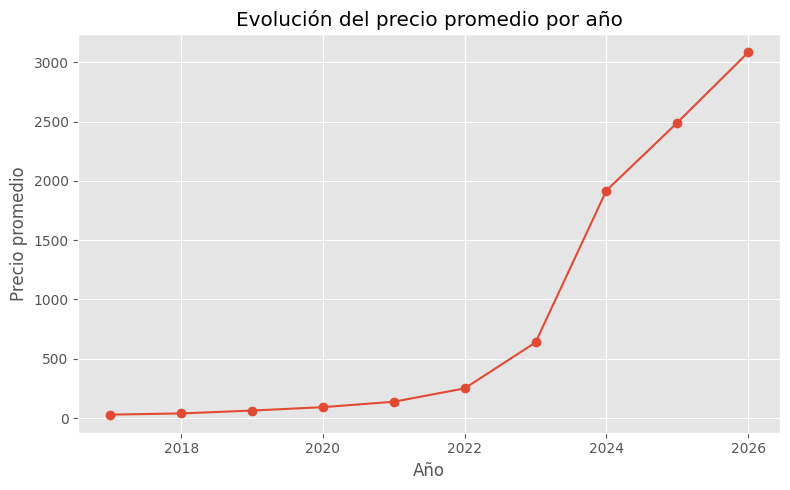

In [88]:
plt.figure(figsize=(8,5))

plt.plot(
    precio_promedio_anual.index,
    precio_promedio_anual.values,
    marker="o"
)

plt.title("Evolución del precio promedio por año")
plt.xlabel("Año")
plt.ylabel("Precio promedio")
plt.grid(True)

plt.tight_layout()
plt.show()

### 9.2 Precio promedio por región
Se compara el precio promedio de los productos entre las distintas regiones del país.

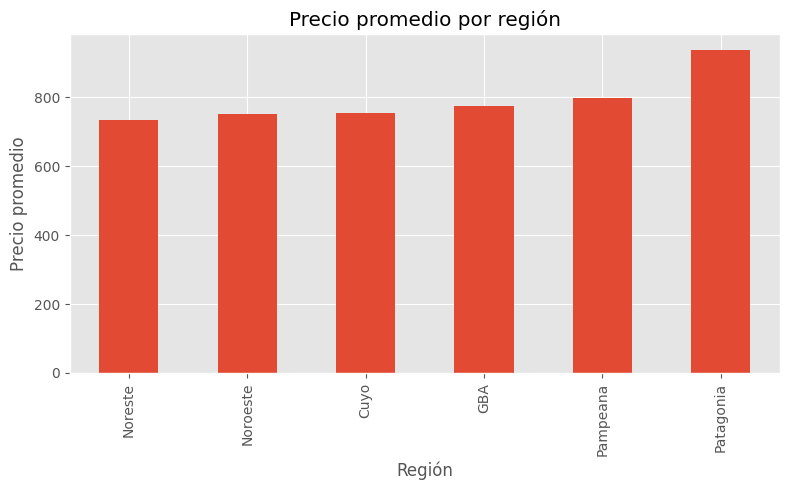

In [89]:
plt.figure(figsize=(8,5))

precio_promedio_region.sort_values().plot(kind="bar")

plt.title("Precio promedio por región")
plt.xlabel("Región")
plt.ylabel("Precio promedio")

plt.tight_layout()
plt.show()

### 9.3 Productos con mayor precio promedio
Se muestran los diez productos con mayor precio promedio durante el período analizado.

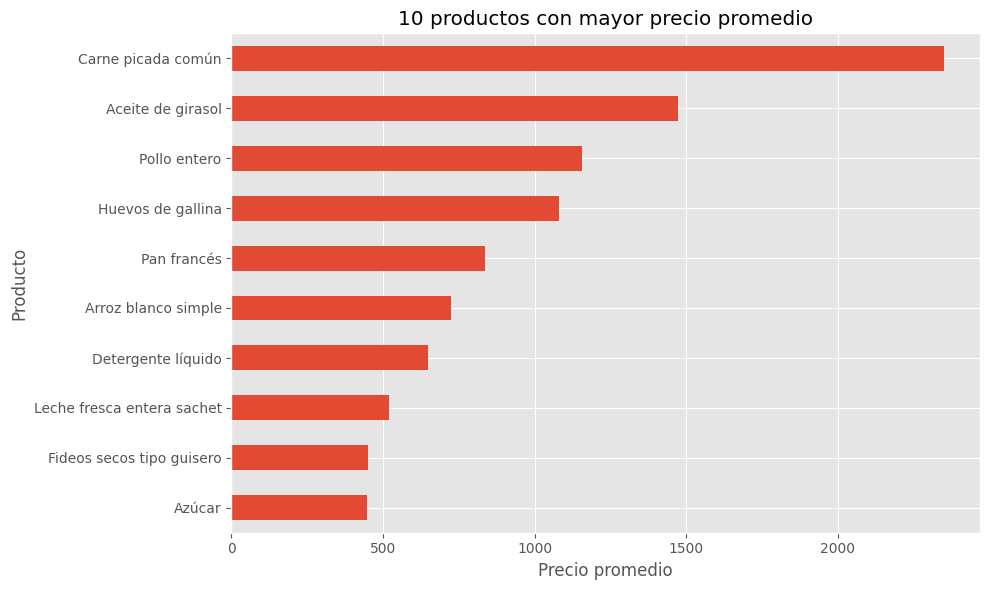

In [90]:
plt.figure(figsize=(10,6))

productos_mas_caros.sort_values().plot(kind="barh")

plt.title("10 productos con mayor precio promedio")
plt.xlabel("Precio promedio")
plt.ylabel("Producto")

plt.tight_layout()
plt.show()

## 10. Conclusiones
* El precio promedio de los productos mostró una tendencia creciente durante el período analizado.
* Se observaron diferencias en los precios promedio entre las distintas regiones del país.
* Algunos productos presentaron precios promedio significativamente superiores al resto.
* La preparación de los datos mediante Python y pandas permitió realizar el análisis de forma estructurada y reproducible.



## 11. Exportación del dataset e importación a Data Studio
Una vez finalizada la limpieza y transformación de los datos en Python, el dataset se exportó en formato CSV para ser utilizado como fuente de datos en Data Studio. Esto permitió construir un dashboard interactivo con gráficos, tablas y filtros para facilitar el análisis de los precios.

In [91]:
df_largo.to_csv("ipc_limpio.csv", index=False)

## 12. Dashboard interactivo en Data Studio
Como complemento del análisis realizado en Python, se desarrolló un dashboard interactivo en Data Studio utilizando el dataset limpio generado durante este proyecto. El tablero permite explorar la información mediante gráficos e indicadores dinámicos, facilitando la interpretación de los resultados.

El dashboard incluye:
*   Evolución del precio promedio por año
*   Precio promedio por Región
*   Tablas de precios por región, producto y período
*   Top 10 productos con mayor precio promedio
*   Filtros por año, región y producto








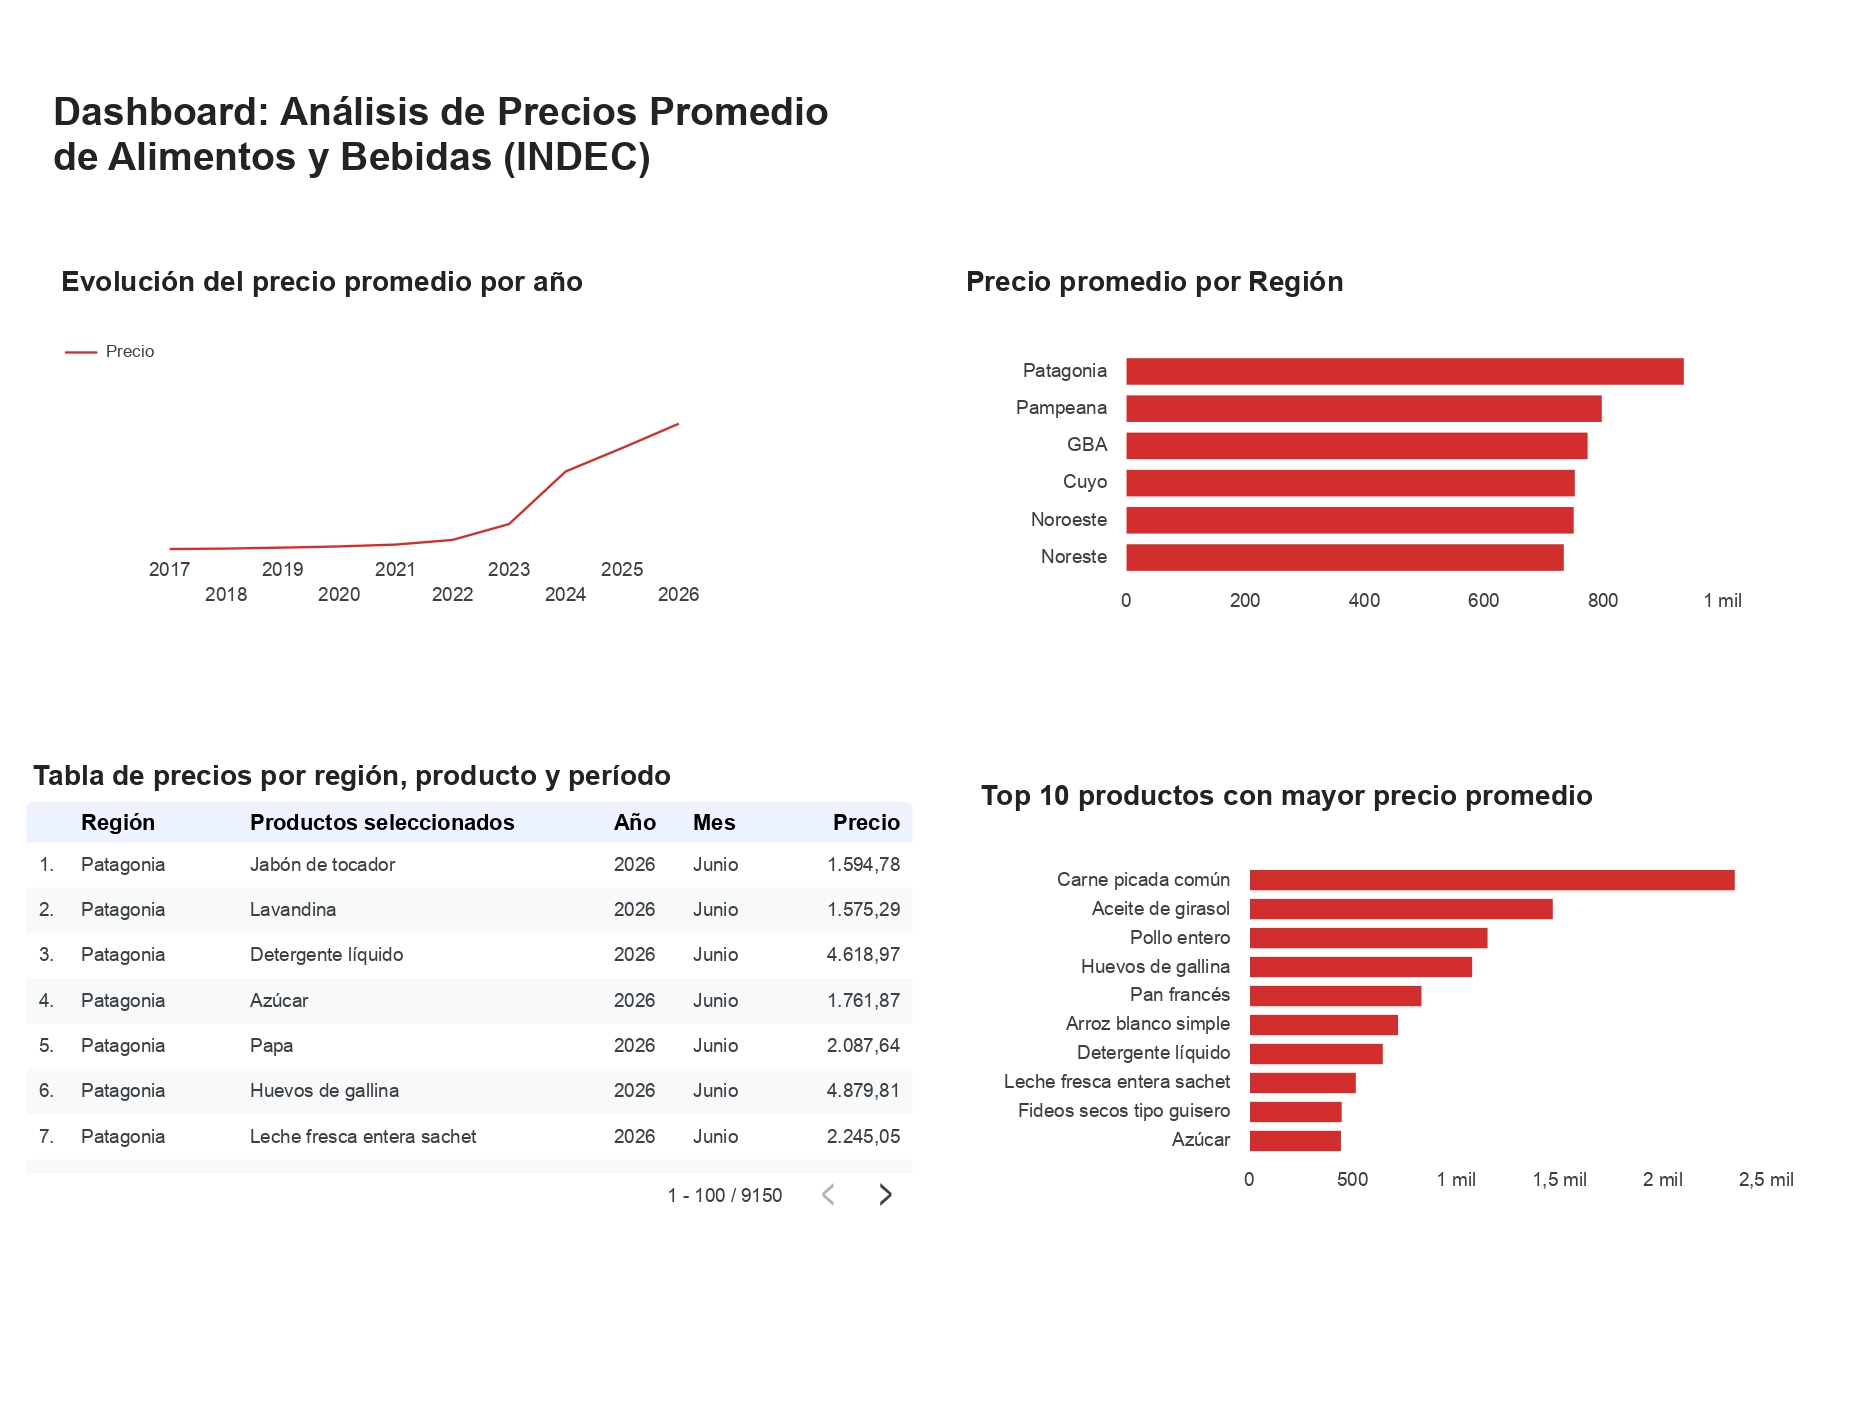

In [92]:
from IPython.display import Image, display

display(Image("Análisis de Precios Promedio de Alimentos y Bebidas (INDEC).jpg"))

## Dashboard Interactivo

El dashboard interactivo fue desarrollado en Data Studio y puede consultarse en el siguiente enlace:

🔗 Dashboard: https://datastudio.google.com/u/0/reporting/05bca233-a618-433c-bd4f-48fe7144c6cc/page/WIv4F

# 13. Conclusión final

En este proyecto se realizó el proceso completo de preparación y análisis de datos utilizando información oficial del Índice de Precios al Consumidor (IPC) publicada por el INDEC. A partir de un archivo Excel con una estructura compleja, se aplicaron tareas de limpieza, transformación y organización de los datos mediante Python y la biblioteca Pandas.

Posteriormente, el conjunto de datos fue exportado e integrado en Data Studio para desarrollar un dashboard interactivo que permite analizar la evolución de los precios promedio, comparar regiones, identificar los productos con mayor precio promedio y explorar la información mediante filtros dinámicos.

Este proyecto permitió aplicar conocimientos de análisis de datos, limpieza y transformación de información, visualización de datos y desarrollo de un dashboard interactivo, integrando herramientas ampliamente utilizadas en el ámbito del análisis de datos como Python, Pandas y Data Studio.